In [6]:
import pandas as pd
ufo=pd.read_csv('https://bit.ly/uforeports')
print(ufo.isnull().tail())
print(ufo.notnull().tail())
print(ufo.isnull().sum())
print(ufo.shape)
print(ufo.dropna(how='all').shape)
print(ufo.dropna(subset=['City','Shape Reported'],how='any').shape)
print(ufo['Shape Reported'].value_counts().head())
print(ufo['Shape Reported'].fillna(value='VARIOUS',inplace=True))
print(ufo['Shape Reported'].value_counts().head())
drinks=pd.read_csv('http://bit.ly/drinksbycountry')
print(drinks.head())
print(drinks.index)
print(pd.read_table('http://bit.ly/movieusers',header=None,sep='|').head())
print(drinks[drinks.continent=='South America'])
print(drinks.loc[23,'beer_servings'])

        City  Colors Reported  Shape Reported  State   Time
18236  False             True           False  False  False
18237  False             True           False  False  False
18238  False             True            True  False  False
18239  False            False           False  False  False
18240  False             True           False  False  False
       City  Colors Reported  Shape Reported  State  Time
18236  True            False            True   True  True
18237  True            False            True   True  True
18238  True            False           False   True  True
18239  True             True            True   True  True
18240  True            False            True   True  True
City                  26
Colors Reported    15359
Shape Reported      2644
State                  0
Time                   0
dtype: int64
(18241, 5)
(18241, 5)
(15575, 5)
Shape Reported
LIGHT       2803
DISK        2122
TRIANGLE    1889
OTHER       1402
CIRCLE      1365
Name: count, dtype: i

Coefficients: 
 [938.23786125]
Mean squared error:2548.072399
Coefficient of determination:0.472575


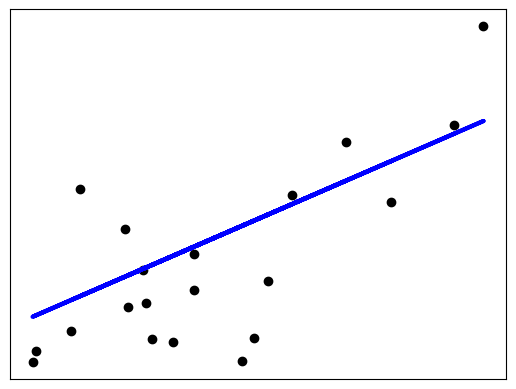

In [7]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets,linear_model
from sklearn.metrics import mean_squared_error,r2_score

diabetes_X,diabetes_y=datasets.load_diabetes(return_X_y=True)

diabetes_X=diabetes_X[:,np.newaxis,2]

diabetes_X_train=diabetes_X[:-20]
diabetes_X_test=diabetes_X[-20:]

diabetes_y_train=diabetes_y[:-20]
diabetes_y_test=diabetes_y[-20:]

regr=linear_model.LinearRegression()
regr.fit(diabetes_X_train,diabetes_y_train)

diabetes_y_pred=regr.predict(diabetes_X_test)

print('Coefficients: \n',regr.coef_)
print('Mean squared error:%2f'%mean_squared_error(diabetes_y_test,diabetes_y_pred))
print('Coefficient of determination:%2f'%r2_score(diabetes_y_test,diabetes_y_pred))
plt.scatter(diabetes_X_test,diabetes_y_test, color='black')
plt.plot(diabetes_X_test, diabetes_y_pred, color='blue',linewidth=3)
plt.xticks(())
plt.yticks(())
plt.show()

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
iris=load_iris()
x=iris.data
y=iris.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
c_knn=KNeighborsClassifier(n_neighbors=3)
c_knn.fit(x_train,y_train)
y_pred=c_knn.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test,y_pred))
sample=[[2,2,2,2]]
pred=c_knn.predict(sample)
pred_v=[iris.target_names[p] for p in pred]
print(pred_v)

Accuracy: 0.9777777777777777
['setosa']


In [12]:
from sklearn.datasets import load_iris
from sklearn .model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
X,y=load_iris(return_X_y=True)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.5,random_state=0)
gnb=GaussianNB()
y_pred=gnb.fit(X_train,y_train).predict(X_test)
print(y_pred)
x_new=[[5,5,4,4]]
y_new=gnb.fit(X_train,y_train).predict(x_new)
print("predicted output for [[5,5,4,4]]:",y_new)
print("Naive bayes score:",gnb.score(X_test,y_test))

[2 1 0 2 0 2 0 1 1 1 1 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0 1 2 2 1 2 1 2 1 1 2 1 1 2 1 2 1 0 2 1 1 1 1 2 0 0 2 1 0 0
 1]
predicted output for [[5,5,4,4]]: [2]
Naive bayes score: 0.9466666666666667


In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
data=load_iris()
data.data.shape
print('classes to predict:',data.target_names)
print('Features:',data.feature_names)
X=data.data
y=data.target
display(X.shape,y.shape)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=50,test_size=0.25)
classifier=DecisionTreeClassifier()
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
from sklearn.metrics import accuracy_score
print('Accuracy on train data using Gini:',accuracy_score(y_true=y_train,y_pred=classifier.predict(X_train)))
print('Accuracy on test data using Gini:',accuracy_score(y_true=y_test,y_pred=y_pred))
classifier_entropy=DecisionTreeClassifier(criterion='entropy')
classifier_entropy.fit(X_train,y_train)
y_pred_entropy=classifier_entropy.predict(X_test)
print('Accuracy on test data using entropy',accuracy_score(y_true=y_test,y_pred=y_pred_entropy))
classifier_entropy1=DecisionTreeClassifier(criterion='entropy',min_samples_split=50)
classifier_entropy1.fit(X_train,y_train)
y_pred_entropy1=classifier_entropy1.predict(X_test)
print('Accuracy on train data using entropy',accuracy_score(y_true=y_train,y_pred=classifier_entropy1.predict(X_train)))
print('Accurcy on test data using entropy',accuracy_score(y_true=y_test,y_pred=y_pred_entropy1))
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus
dot_data=StringIO()
export_graphviz(classifier,out_file=dot_data,filled=True,rounded=True,special_characters=True,feature_names=data.feature_names,class_names=data.target_names)
graph=pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

classes to predict: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


(150, 4)

(150,)

Accuracy on train data using Gini: 1.0
Accuracy on test data using Gini: 0.9473684210526315
Accuracy on test data using entropy 0.9473684210526315
Accuracy on train data using entropy 0.9642857142857143
Accurcy on test data using entropy 0.9473684210526315


InvocationException: GraphViz's executables not found